In [1]:
import healpy as hp
from scripts.utils import plot_cl_alm, load_data
from scripts.config import SimConfig

import matplotlib.pyplot as plt
from pixell import enmap, lensing, curvedsky, reproject
import numpy as np

In [2]:
# from scripts.utils import get_radii
from ksw import Cosmology, Data
import camb
from ksw.radial_functional import radial_func
from tqdm.auto import tqdm

from scipy.interpolate import CubicSpline
from joblib import Parallel, delayed

In [3]:
config_file = "settings/scraped.json"
s = SimConfig(config_file)

Loaded settings from file: settings/scraped.json
{ 'alm_cache_dir': 'data/alm_cache',
  'base_dir': 'data',
  'beam_width': 7.1,
  'cosmo_params': { 'AccuracyBoost': 2.0,
                    'As': 2.457e-09,
                    'DoLateRadTruncation': False,
                    'H0': 70.1,
                    'TCMB': 2.7255,
                    'lAccuracyBoost': 2.0,
                    'lSampleBoost': 2.0,
                    'lens_potential_accuracy': 2,
                    'lmax': 1024,
                    'max_l': 1500,
                    'mnu': 0.06,
                    'ns': 0.96,
                    'ombh2': 0.02256,
                    'omch2': 0.1143,
                    'pivot_scalar': 0.05,
                    'r': 0,
                    'tau': 0.084},
  'debug': True,
  'disable_noise': True,
  'double_precision': False,
  'fnl_range': [0, 0],
  'force_alm_gen': True,
  'lensing': False,
  'name': 'scraped',
  'narray': 1,
  'noise_scale_ee': 4.3,
  'noise_scale_te': 0.43,


In [4]:
t_scale = (s.cosmo_params['TCMB'] * 10**(6)) 
lhdus = (1, 2, 3) if s.npol > 1 else 1

base1 = "scraped/alm_l_0001_v3.fits"
alm_heidelberg_l = hp.read_alm(base1, hdu=lhdus) * t_scale

base2 = "scraped/alm_nl_0001_v3.fits"
alm_heidelberg_nl = hp.read_alm(base2, hdu=lhdus) * t_scale


In [5]:
camb_params_obj = camb.set_params(**s.cosmo_params, verbose=s.verbose)
cosmo = Cosmology(camb_params_obj, verbose=s.verbose)
cosmo.compute_transfer(s.cosmo_params["max_l"], verbose=s.verbose)
cosmo.compute_c_ell()

noise_ell, beam_ell = s.get_noise_beam()
ksw_data = Data(s.lmax, noise_ell, beam_ell, s.polarizations, cosmo)

c_ells = ksw_data.cosmology.c_ell["unlensed_scalar"]["c_ell"]  # type: ignore
tr_ell_k = ksw_data.cosmology.transfer["tr_ell_k"]
tr_ells = ksw_data.cosmology.transfer["ells"]
tr_k = ksw_data.cosmology.transfer["k"]

mask = tr_ells <= s.lmax
tr_ell_k = tr_ell_k[mask]
tr_ells = tr_ells[mask]

Updated CAMB param: BessIntBoost from 1.0 to 30.
Updated CAMB param: KmaxBoost from 1.0 to 3.
Updated CAMB param: IntTolBoost from 1.0 to 4.
Updated CAMB param: TimeStepBoost from 1.0 to 4.
Updated CAMB param: SourcekAccuracyBoost from 1.0 to 5.
Updated CAMB param: BesselBoost from 1.0 to 5.
Updated CAMB param: IntkAccuracyBoost from 1.0 to 5.
Updated CAMB param: AccurateBB from False to True.


In [6]:
def get_radii(r_min, r_max):
    # For the radii we follow Table 2. of Smith and Zaldarriaga which gives a greater density of points near reionization and recombination.
    #
    # Spacing for all ranges but the last row are linear, with the last row having log spacing.
    #
    # radii are in Mpc
    radii = []
    #          start,  stop, resolution
    ranges = [
        (0, 9500, 150),
        (9500, 11000, 300),
        (11000, 13800, 150),
        (13800, 14600, 400),
        (14600, 16000, 100),
        (16000, 50000, 100),
    ]

    for r in ranges:
        start = max(r_min, r[0])
        end = min(r_max, r[1])

        if start > end:
            continue

        if r == ranges[-1]:  # For the last range, use logspace
            temp_radii = np.logspace(np.log10(start), np.log10(end), num=r[2])
        else:
            temp_radii = np.linspace(start, end, num=r[2], endpoint=False)

        radii.extend(temp_radii)

    radii = np.array([r for r in radii if r_min <= r < r_max])
    drs = np.diff(radii)
    return radii, drs

radii, drs = get_radii(s.settings["r_min"], s.settings["r_max"])

In [7]:
def interpolate_ells(func, ells_sparse, ls, axis=1):
    """Our interpolation function to go from space to dense ells."""
    return CubicSpline(ells_sparse, func, axis)(ls)

def beta_div_cl(c_ells):
    div = beta_ell / c_ells[None, tr_ells, None]#, : s.npol]
    bl_div_cl = np.concatenate(np.array([interpolate_ells(div, tr_ells, s.ells)]))
    bl_div_cl = np.ascontiguousarray(bl_div_cl)
    return bl_div_cl

A = (3/5)**2
delta_phi = 2 * np.pi**2 * s.cosmo_params["As"] / (tr_k ** 3) * 3/5 * np.sqrt(1/2)
delta_phi *= (tr_k / s.cosmo_params["pivot_scalar"])**((s.cosmo_params["ns"]-1))

f_k = np.ones((len(tr_k), 2), dtype=s.r_dtype) * (5 / 3)                        # f_k for alpha
f_k[:, 1] *= delta_phi  # f_k for beta

rad = radial_func(f_k, tr_ell_k, tr_k, radii, tr_ells)

alpha_ell = rad[:, :, :, 0]
alpha_l = np.concatenate(np.array([interpolate_ells(alpha_ell, tr_ells, s.ells)]))
alpha_l = np.ascontiguousarray(alpha_l)

beta_ell = rad[:, :, :, 1]

In [8]:
def get_alm(alm, bl_div_cl, alpha_l, r, dr):
    """This calculates the alms from the precalculated values"""
    Balm = hp.almxfl(alm, bl_div_cl)
    B = hp.alm2map(Balm, nside=s.nside)
    inner = hp.map2alm(B**2, lmax=s.lmax, use_pixel_weights=True)
    kernel = hp.almxfl(inner, alpha_l)
    return dr * r**2 * kernel

In [9]:
# cl_heidelberg = curvedsky.alm2cl(alm_heidelberg_l.copy())
# bl_div_cl = beta_div_cl(cl_heidelberg)
bl_div_cl = beta_div_cl(c_ells[:, 0])

alm_gen = Parallel(
    n_jobs=-1, verbose=1, return_as="generator"
)(
    delayed(get_alm)(
        alm_heidelberg_l.copy(),
        bl_div_cl[ri, :, 0],
        alpha_l[ri, :, 0],
        radii[ri],
        drs[ri],
    )
    for ri in range(len(drs))
)

# consume
alm_hybrid_ng = np.zeros((s.nelem), dtype=s.c_dtype)
for alm in alm_gen:
    alm_hybrid_ng += alm

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    8.7s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   18.1s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   30.7s
[Parallel(n_jobs=-1)]: Done 1199 out of 1199 | elapsed:   47.8s finished


In [10]:
alm_sim_g = np.array(
    [
        ksw_data.compute_alm_sim(s.lensing)
        for _ in tqdm(range(s.nsims), desc="a_lm progress")
    ],
    dtype=s.c_dtype,
)
alm_sim_g = alm_sim_g[0,0]

a_lm progress:   0%|          | 0/1 [00:00<?, ?it/s]

In [11]:
# sim_cls = curvedsky.alm2cl(alm_sim_g)
# bl_div_cl = beta_div_cl(c_ells[:, 0])
# bl_div_cl = beta_div_cl(sim_cls)

alm_gen = Parallel(
    n_jobs=-1, verbose=1, return_as="generator"
)(
    delayed(get_alm)(
        alm_sim_g,
        bl_div_cl[ri, :, 0],
        alpha_l[ri, :, 0],
        radii[ri],
        drs[ri],
    )
    for ri in range(len(drs))
)

# consume
alm_sim_ng = np.zeros((s.nelem), dtype=s.c_dtype)
for alm in alm_gen:
    alm_sim_ng += alm

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   15.2s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   27.8s
[Parallel(n_jobs=-1)]: Done 1199 out of 1199 | elapsed:   44.4s finished


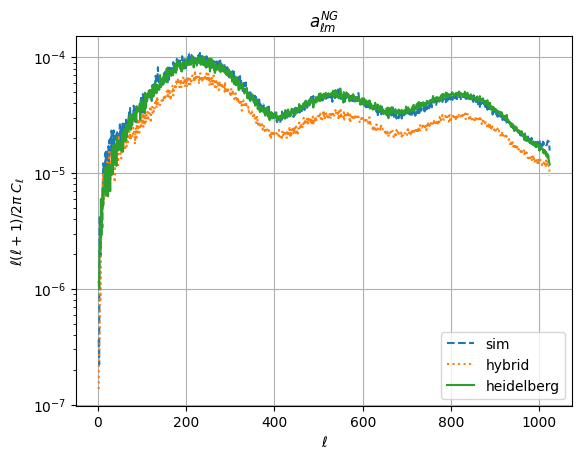

In [12]:
cl_sim = curvedsky.alm2cl(alm_sim_ng.copy())[2:s.lmax]
cl_hybrid = curvedsky.alm2cl(alm_hybrid_ng.copy())[2:s.lmax]
cl_heidelberg = curvedsky.alm2cl(alm_heidelberg_nl.copy())[2:s.lmax]

ells = np.arange(2, s.lmax)
scale = ells * (ells + 1) / 2 / np.pi

plt.figure()
plt.semilogy(ells, scale*cl_sim, label="sim", linestyle='--')
plt.semilogy(ells, scale*cl_hybrid, label="hybrid", linestyle=':')
plt.semilogy(ells, scale*cl_heidelberg, label="heidelberg")

plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell(\ell+1)/2\pi\;C_{\ell}$")
plt.title('$a_{\ell m}^{NG}$')
plt.legend()
plt.grid()

plt.show()
plt.close()

In [13]:
(cl_heidelberg / cl_hybrid)[400:420]

array([1.4050192 , 1.52091735, 1.50933627, 1.28347111, 1.35684272,
       1.40333236, 1.46707426, 1.34560215, 1.30622107, 1.45287961,
       1.47155197, 1.3911249 , 1.51708013, 1.60462413, 1.53613598,
       1.48109142, 1.40614335, 1.50846673, 1.42654796, 1.39040025])

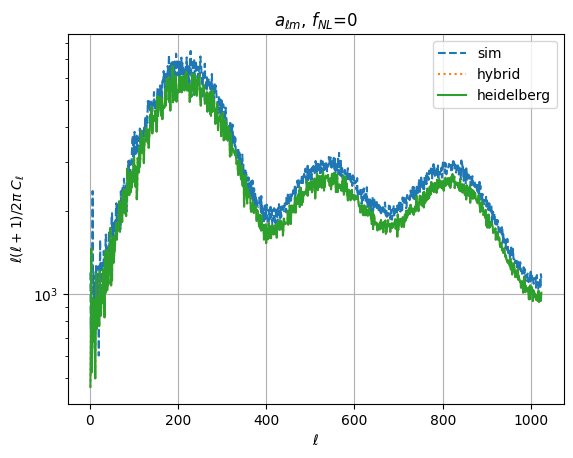

In [14]:
fnl = 0
lmax = hp.Alm.getlmax(len(alm_sim_ng))

# cl_sim_ng = curvedsky.alm2cl(alm_sim_ng)
# cl_hybrid = curvedsky.alm2cl(alm_hybrid_ng)

alm_sim = alm_sim_g + fnl * alm_sim_ng
alm_hybrid = alm_heidelberg_l + fnl * alm_hybrid_ng
alm_heidelberg = alm_heidelberg_l + fnl * alm_heidelberg_nl

cl_sim = curvedsky.alm2cl(alm_sim)[2:lmax]
cl_hybrid = curvedsky.alm2cl(alm_hybrid)[2:lmax]
cl_heidelberg = curvedsky.alm2cl(alm_heidelberg)[2:lmax]

plt.figure()
plt.semilogy(ells, scale*cl_sim, label="sim", linestyle='--')
plt.semilogy(ells, scale*cl_hybrid, label="hybrid", linestyle=':')
plt.semilogy(ells, scale*cl_heidelberg, label="heidelberg")

plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell(\ell+1)/2\pi\;C_{\ell}$")
plt.title('$a_{\ell m}$, $f_{NL}$=' + str(fnl))
plt.legend()
plt.grid()

plt.show()
plt.close()
